## Modelos VECM

#### _Una vez que se conoce que hay cointegración de los datos, es encontrado un régimen se  aplicar un modelo VEC_

In [14]:
import datetime
import os
from time import strftime
import numpy as np
from datetime import timedelta
from itertools import product
from datetime import datetime
import shutil
import pyodbc
import pandas as pd
import pandasql as psql
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import os
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, select_order
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

scaler = StandardScaler()

user = os.getlogin()

#### _Importar los dato_

In [45]:
for i in ['soya','maiz','trigo']:
    locals()[i] = pd.read_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\precios_filtrados_por_regimenes.xlsx",
                               sheet_name = i,
                               index_col = 0)

#### _Generar el modelo_

Rezagos seleccionados (AIC): 2
Rango de cointegración detectado: 4

🔮 Pronóstico para soya:
✔️ RMSE: 92.87
✔️ MAPE: 6.74%


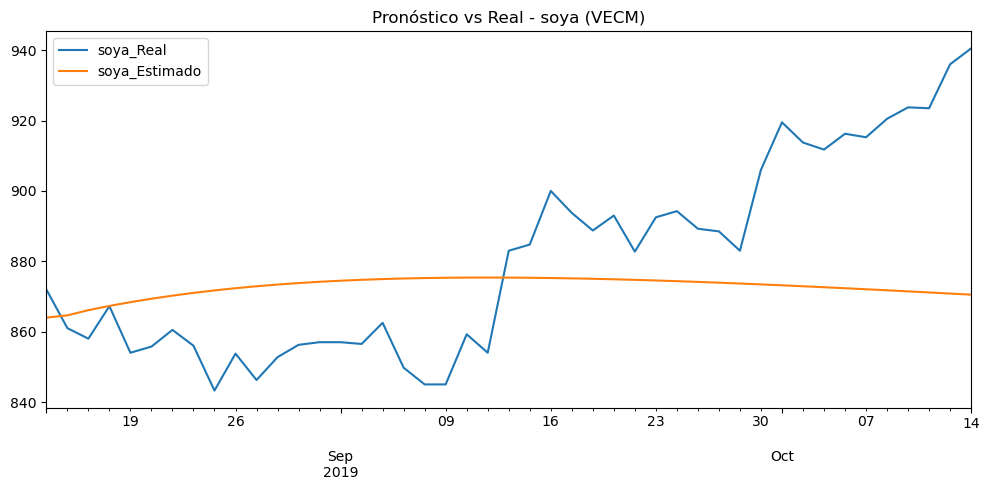

Rezagos seleccionados (AIC): 1
Rango de cointegración detectado: 1

🔮 Pronóstico para maiz:
✔️ RMSE: 50.81
✔️ MAPE: 12.59%


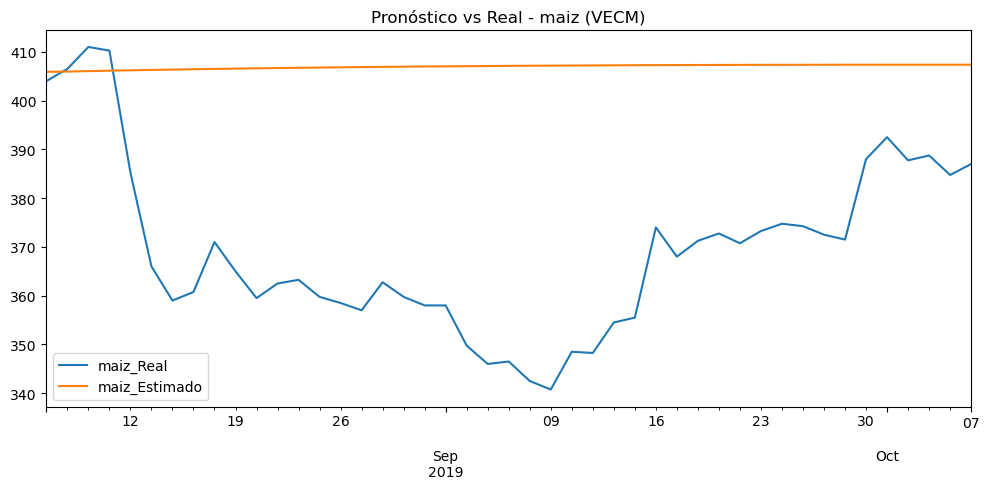

Rezagos seleccionados (AIC): 2
Rango de cointegración detectado: 1

🔮 Pronóstico para trigo:
✔️ RMSE: 55.57
✔️ MAPE: 8.83%


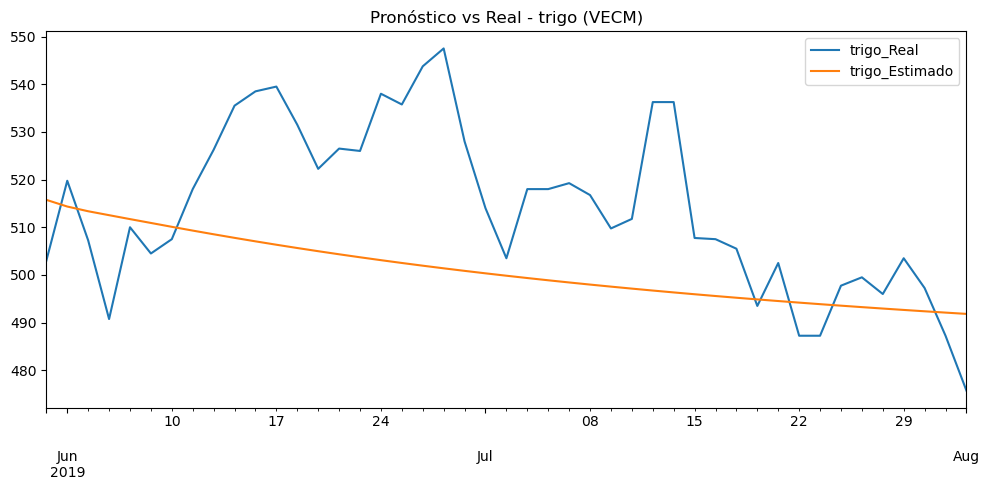

In [49]:
# In[Modelo VECM]


variables = {'soya':['Stock/Consumo','petroleo','diesel'], # Las variables que se encuentran en el diccionario corresponden a las que serán usadas por cada modelo
             'maiz':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural'],
             'trigo':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural']}

for i in variables.keys():
    
    # Se genera la serie que será analizada, utilizando solo los años que se encuentran en el régimen 1
    y = locals()[i]
    
    # Crear un rango de fechas continuo desde la primera hasta la última
    rango_fechas = pd.date_range(start=y.index.min(), end=y.index.max(), freq="B")
    
    # Reindexar el DataFrame a ese rango de días hábiles
    y = y.reindex(rango_fechas)
    
    # Rellenar los datos incompletos para poder tener una frecuencia marcada
    y.ffill(inplace = True) 

    # 1. Separar datos en 80% entrenamiento y 20% test (sin mezclar)
    split_index = int(len(y) * 0.80)
    train_df = y.iloc[:split_index]
    test_df = y.iloc[split_index:]

    # 2. Selección de rezagos óptimos
    lag_order = select_order(train_df, maxlags=5, deterministic="co")
    k_ar_diff = lag_order.aic
    print(f"Rezagos seleccionados (AIC): {k_ar_diff}")

    # 3. Selección de cointegración
    rank_test = select_coint_rank(train_df, det_order=0, k_ar_diff=k_ar_diff, method="trace")
    print(f"Rango de cointegración detectado: {rank_test.rank}")

    # 4. Ajuste del modelo VECM
    model = VECM(train_df, k_ar_diff=k_ar_diff, coint_rank=rank_test.rank, deterministic="co")
    vecm_fit = model.fit()

    # 5. Predicción sobre test
    steps = len(test_df)
    forecast = vecm_fit.predict(steps=steps)
    forecast_df = pd.DataFrame(forecast, columns=y.columns, index=test_df.index)

    # 6. Evaluación del modelo para la variable principal
    y_true = test_df[i]
    y_pred = forecast_df[i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n🔮 Pronóstico para {i}:")
    print(f"✔️ RMSE: {rmse:.2f}")
    print(f"✔️ MAPE: {mape:.2f}%")

    # 7. Graficar resultados
    combined = pd.concat([y_true, y_pred], axis=1)
    combined.columns = [f"{i}_Real", f"{i}_Estimado"]

    combined.iloc[:45,:].plot(title=f"Pronóstico vs Real - {i} (VECM)", figsize=(10, 5))
    plt.tight_layout()
    plt.show()
